# 03 Result Analysis

This notebook performs proposal-level interpretation using segment metrics from each model output. It is designed to answer the final research question directly.


## Goals

1. Compare models by prefix-length and session-length segments.
2. Evaluate whether sequence advantages increase with context length.
3. Generate conclusion-ready tables and decision statements.


In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image, display

# Prefer inline rendering in notebooks so plots appear in output cells.
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

def show_saved_or_inline(saved_path: Path) -> None:
    """Show the plot inline when possible; otherwise display the saved PNG file."""
    backend = plt.get_backend().lower()
    if "agg" in backend:
        display(Image(filename=str(saved_path)))
    else:
        plt.show()
    plt.close()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

metric_paths = sorted(METRICS_DIR.glob("*_test.json"))
if not metric_paths:
    raise FileNotFoundError("No metrics JSON files found in outputs/metrics/. Run experiments first.")

payloads = {}
for path in metric_paths:
    with path.open("r", encoding="utf-8") as fp:
        payloads[path.stem] = json.load(fp)

print("Loaded", len(payloads), "model payloads")




Loaded 6 model payloads


In [2]:
# Build a headline table.
headline_rows = []
for key, p in payloads.items():
    overall = p["metrics"]["overall"]
    headline_rows.append(
        {
            "model_name": p["model_name"],
            "HitRate@10": overall.get("HitRate@10", np.nan),
            "Recall@20": overall.get("Recall@20", np.nan),
            "MRR@20": overall.get("MRR@20", np.nan),
            "NDCG@20": overall.get("NDCG@20", np.nan),
            "runtime_seconds": p["metrics"].get("runtime_seconds", np.nan),
        }
    )

headline = pd.DataFrame(headline_rows).sort_values("HitRate@10", ascending=False)
headline



,model_name,HitRate@10,Recall@20,MRR@20,NDCG@20,runtime_seconds
4,session_knn_unordered,0.174574,0.216687,0.086995,0.116083,2661.078774
3,session_knn_sequence,0.171486,0.212639,0.085966,0.114388,2540.786583
5,weighted_markov,0.160526,0.188150,0.085255,0.108652,8687.346895
1,markov,0.144450,0.161463,0.079550,0.098451,2982.610994
0,cooccurrence,0.140178,0.180503,0.069697,0.094382,27954.210025
2,popularity,0.005635,0.008034,0.001241,0.002718,3939.119048


In [3]:
# Extract prefix-bucket metrics into long format.
prefix_rows = []
for _, p in payloads.items():
    model_name = p["model_name"]
    by_prefix = p["metrics"].get("by_prefix_length", {})
    for bucket, metrics in by_prefix.items():
        prefix_rows.append(
            {
                "model_name": model_name,
                "bucket": bucket,
                "HitRate@10": metrics.get("HitRate@10", np.nan),
                "Recall@20": metrics.get("Recall@20", np.nan),
                "MRR@20": metrics.get("MRR@20", np.nan),
                "NDCG@20": metrics.get("NDCG@20", np.nan),
            }
        )

prefix_df = pd.DataFrame(prefix_rows)
prefix_df.head()



,model_name,bucket,HitRate@10,Recall@20,MRR@20,NDCG@20
0,cooccurrence,prefix_1,0.200395,0.244118,0.105166,0.136501
1,cooccurrence,prefix_2,0.114322,0.155541,0.053758,0.076254
2,cooccurrence,prefix_3_5,0.126002,0.170463,0.058346,0.083097
3,cooccurrence,prefix_6_plus,0.060145,0.089049,0.026127,0.039790
4,markov,prefix_1,0.216566,0.238121,0.123803,0.150382


In [4]:
# Extract session-length-bucket metrics into long format.
session_rows = []
for _, p in payloads.items():
    model_name = p["model_name"]
    by_len = p["metrics"].get("by_session_length", {})
    for bucket, metrics in by_len.items():
        session_rows.append(
            {
                "model_name": model_name,
                "bucket": bucket,
                "HitRate@10": metrics.get("HitRate@10", np.nan),
                "Recall@20": metrics.get("Recall@20", np.nan),
                "MRR@20": metrics.get("MRR@20", np.nan),
                "NDCG@20": metrics.get("NDCG@20", np.nan),
            }
        )

session_df = pd.DataFrame(session_rows)
session_df.head()



,model_name,bucket,HitRate@10,Recall@20,MRR@20,NDCG@20
0,cooccurrence,session_long_7_plus,0.088157,0.122828,0.039890,0.058087
1,cooccurrence,session_medium_4_6,0.144209,0.189522,0.068616,0.095471
2,cooccurrence,session_short_2_3,0.186625,0.229114,0.098460,0.127882
3,markov,session_long_7_plus,0.091502,0.104688,0.047369,0.060477
4,markov,session_medium_4_6,0.141882,0.159932,0.075372,0.094816


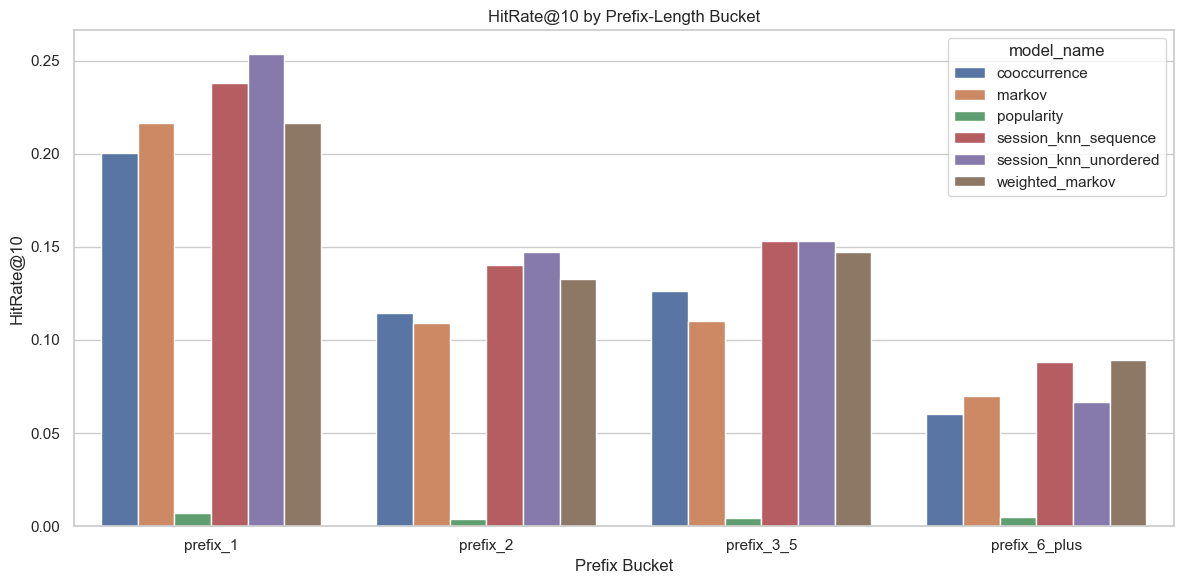

In [5]:
# Plot HitRate@10 by prefix bucket.
if not prefix_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=prefix_df, x="bucket", y="HitRate@10", hue="model_name")
    plt.title("HitRate@10 by Prefix-Length Bucket")
    plt.xlabel("Prefix Bucket")
    plt.ylabel("HitRate@10")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "analysis_hitrate10_by_prefix_bucket.png", dpi=150)
    show_saved_or_inline(FIGURES_DIR / "analysis_hitrate10_by_prefix_bucket.png")
else:
    print("Prefix metrics were not found in model payloads.")



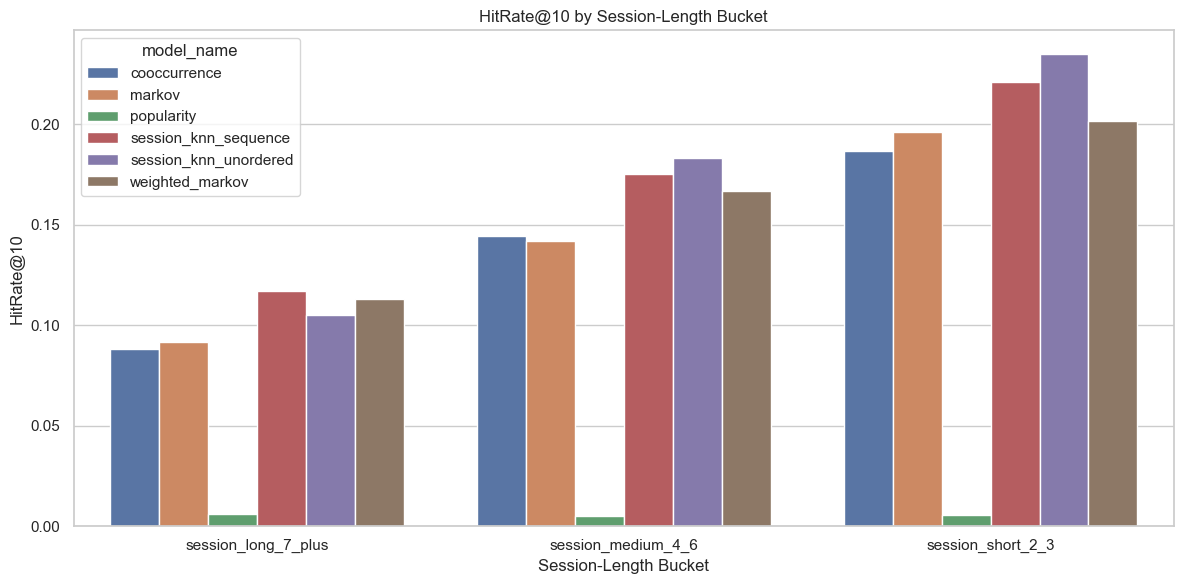

In [6]:
# Plot HitRate@10 by full session-length bucket.
if not session_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=session_df, x="bucket", y="HitRate@10", hue="model_name")
    plt.title("HitRate@10 by Session-Length Bucket")
    plt.xlabel("Session-Length Bucket")
    plt.ylabel("HitRate@10")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "analysis_hitrate10_by_session_bucket.png", dpi=150)
    show_saved_or_inline(FIGURES_DIR / "analysis_hitrate10_by_session_bucket.png")
else:
    print("Session-length metrics were not found in model payloads.")



In [7]:
# Compare a canonical sequence-aware model against a canonical unordered baseline.
# You can change this mapping if your final chosen pair differs.
comparison_pairs = [
    ("markov", "cooccurrence"),
    ("weighted_markov", "cooccurrence"),
    ("session_knn_sequence", "session_knn_unordered"),
]

def metric_lookup(df, model_name, bucket, metric):
    rows = df[(df["model_name"] == model_name) & (df["bucket"] == bucket)]
    if rows.empty:
        return np.nan
    return float(rows.iloc[0][metric])

pairwise_rows = []
for seq_model, base_model in comparison_pairs:
    for bucket in sorted(prefix_df["bucket"].unique()):
        seq_value = metric_lookup(prefix_df, seq_model, bucket, "HitRate@10")
        base_value = metric_lookup(prefix_df, base_model, bucket, "HitRate@10")
        pairwise_rows.append(
            {
                "comparison": f"{seq_model} - {base_model}",
                "segment_type": "prefix",
                "bucket": bucket,
                "seq_value": seq_value,
                "base_value": base_value,
                "absolute_gain": seq_value - base_value,
            }
        )

    for bucket in sorted(session_df["bucket"].unique()):
        seq_value = metric_lookup(session_df, seq_model, bucket, "HitRate@10")
        base_value = metric_lookup(session_df, base_model, bucket, "HitRate@10")
        pairwise_rows.append(
            {
                "comparison": f"{seq_model} - {base_model}",
                "segment_type": "session_length",
                "bucket": bucket,
                "seq_value": seq_value,
                "base_value": base_value,
                "absolute_gain": seq_value - base_value,
            }
        )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df.head(20)



,comparison,segment_type,bucket,seq_value,base_value,absolute_gain
0,markov - cooccurrence,prefix,prefix_1,0.216566,0.200395,0.016171
1,markov - cooccurrence,prefix,prefix_2,0.109079,0.114322,-0.005243
2,markov - cooccurrence,prefix,prefix_3_5,0.110003,0.126002,-0.016000
3,markov - cooccurrence,prefix,prefix_6_plus,0.069631,0.060145,0.009487
4,markov - cooccurrence,session_length,session_long_7_plus,0.091502,0.088157,0.003344
5,markov - cooccurrence,session_length,session_medium_4_6,0.141882,0.144209,-0.002327
6,markov - cooccurrence,session_length,session_short_2_3,0.195956,0.186625,0.009331
7,weighted_markov - cooccurrence,prefix,prefix_1,0.216566,0.200395,0.016171
8,weighted_markov - cooccurrence,prefix,prefix_2,0.132864,0.114322,0.018542
9,weighted_markov - cooccurrence,prefix,prefix_3_5,0.147160,0.126002,0.021157


In [8]:
# Save analysis tables.
headline.to_csv(TABLES_DIR / "analysis_headline_table.csv", index=False)
prefix_df.to_csv(TABLES_DIR / "analysis_prefix_metrics_long.csv", index=False)
session_df.to_csv(TABLES_DIR / "analysis_session_metrics_long.csv", index=False)
pairwise_df.to_csv(TABLES_DIR / "analysis_pairwise_segment_gains.csv", index=False)

print("Wrote analysis tables to outputs/tables/")



Wrote analysis tables to outputs/tables/


In [9]:
# Build a proposal-answer helper summary.
# This converts numeric comparisons into compact statements to support the final report.

def winner_for_metric(df, metric):
    if df.empty:
        return None
    return df.sort_values(metric, ascending=False).iloc[0]["model_name"]

best_hitrate10_model = winner_for_metric(headline, "HitRate@10")
best_mrr20_model = winner_for_metric(headline, "MRR@20")

summary_statements = {
    "best_model_hitrate10": best_hitrate10_model,
    "best_model_mrr20": best_mrr20_model,
    "proposal_question": "Do sequence-aware models outperform unordered baselines?",
    "note": "Use pairwise segment gains and headline tables to finalize this decision in documentation/3-results-summary.md",
}

summary_statements



{'best_model_hitrate10': 'session_knn_unordered',
 'best_model_mrr20': 'session_knn_unordered',
 'proposal_question': 'Do sequence-aware models outperform unordered baselines?',
 'note': 'Use pairwise segment gains and headline tables to finalize this decision in documentation/3-results-summary.md'}

## Final conclusion workflow

1. Use `analysis_headline_table.csv` for the primary performance ranking.
2. Use `analysis_pairwise_segment_gains.csv` to verify whether sequence-aware gains increase with context.
3. Write final answers into `documentation/3-results-summary.md` using concrete metric deltas.
